In [135]:
#import relevant libraries
import os
#from scipy import stats

import numpy as np
#import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap


import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout

#NOTE: SUPPRESSES WARNINGS!

import warnings


warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)


In [136]:
#initial file processing
homecomp = "C:\\Users\\Star"
filepath = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Together\\3. Compiled\\"
titledpath = homecomp
openPath = titledpath + filepath
files2 = os.listdir(openPath)

## Code

In [137]:
files2 = os.listdir(openPath)
files2

['46416jus x ACR [ATR] allstats.csv',
 '46416jus x eOPN3 allstats.csv',
 '46416jus x eOPN3-TS-ER allstats.csv',
 'Cha-6798 x eOPN3 allstats.csv',
 'Cha-6798 x eOPN3-TS-ER allstats.csv',
 'ChAT;GCamp x eOPN3 allstats.csv',
 'elav x ACR [ATR] allstats.csv',
 'elav x eOPN3 allstats.csv',
 'elav x eOPN3-TS-ER allstats.csv',
 'nSyb x ACR allstats.csv',
 'nSyb x eOPN3 allstats.csv',
 'nSyb x eOPN3-TS-ER(iii)M1 allstats.csv',
 'nSyb x eOPN3-TS-ER(iii)M2 allstats.csv',
 'nSyb x eOPN3-TS-ER(iii)M4 allstats.csv',
 'nSyb x eOPN3-TS-ER(iii)M5 allstats.csv',
 'OK371 x ACR allstats.csv',
 'OK371 x eOPN3 allstats.csv',
 'OK371 x eOPN3;Gai allstats.csv',
 'OK371 x eOPN3;Gao allstats.csv',
 'Piezo x ACR allstats.csv',
 'Piezo x eOPN3 allstats.csv',
 'Piezo x eOPN3;Gai allstats.csv',
 'Piezo x eOPN3;Gao allstats.csv',
 'Repo x ACR allstats.csv',
 'Repo x eOPN3 allstats.csv',
 'vGAT x eOPN3 allstats.csv',
 'vGAT x eOPN3-TS-ER allstats.csv',
 'vGAT(v) x eOPN3-TS-ER allstats.csv',
 'vGlut x eOPN3 allstats.

In [138]:
## uncomment whichever set you want to look at, do not uncomment everything

files3 = ['nSyb x eOPN3 allstats.csv','nSyb x eOPN3-TS-ER(iii)M4 allstats.csv', 
          '46416jus x eOPN3 allstats.csv', '46416jus x eOPN3-TS-ER allstats.csv',
          'Cha-6798 x eOPN3 allstats.csv', 'Cha-6798 x eOPN3-TS-ER allstats.csv',
 'elav x eOPN3 allstats.csv', 'elav x eOPN3-TS-ER allstats.csv',
 'vGAT x eOPN3 allstats.csv', 'vGAT x eOPN3-TS-ER allstats.csv'
]

# files3 = ['46146jus x ACR[ATR] allstats.csv',
#  '46146jus x eOPN3 allstats.csv',
#  '46146jus x eOPN3[ATR] allstats.csv',
#  'elav x ACR allstats.csv',
#  'elav x eOPN3 allstats.csv'

# ]

# files3 = ['Cha x eOPN3 allstats.csv',
#  'vGAT x eOPN3 allstats.csv', 
# 'nsyb x eOPN3 allstats.csv'
# ]

# files3 = ['OK371 x ACR allstats.csv',
#  'OK371 x eOPN3 allstats.csv',
#  'OK371 x eOPN3-galphai allstats.csv',
#  'OK371 x eOPN3-galphao allstats.csv'
#  ]


# files3 = ['Piezo x ACR allstats.csv',
#  'Piezo x eOPN3 allstats.csv',
#  'Piezo x eOPN3-galphai allstats.csv',
#  'Piezo x eOPN3-galphao allstats.csv']


# files3 = ['nsyb x eOPN3 allstats.csv',
#  'nsyb x PdCO [B] allstats.csv',
#   'Cha x eOPN3 allstats.csv',
#  'Cha x PdCO allstats.csv',]

In [139]:
def pergenotypeplotting(openPath, files2, k): 
    # input is a metric name
    metricname = pd.DataFrame()
    singlemeandiff= pd.DataFrame()
    
    for f in files2:
        samplefile = pd.DataFrame()
        singlemeans = pd.DataFrame()
        newfile2read = pd.read_csv(openPath + f, index_col=0)
        cross = f.replace(" allstats.csv", "")
        samplefile['bootstrap'] = newfile2read[k+"_bootstrap"]
        samplefile['deltag'] = newfile2read[k+"_deltag"]
        samplefile['Cross'] = cross.replace("[ATR]", "*").replace("eOPN3", "AsOPN3").replace("[B]", "").replace("(iii)M4", "")
        samplefile["metric"] = k
        
        singlemeans['mean'] = samplefile['deltag'].unique()
        singlemeans['cross'] = cross.replace("[ATR]", "*").replace("eOPN3", "AsOPN3").replace("[B]", "").replace("(iii)M4", "")
        singlemeans['err'] =  samplefile['bootstrap'].mean() - (samplefile['bootstrap'].mean() - 1.96*(np.std(samplefile['bootstrap'])))  #mean -bca_low (self calculated)

        metricname = pd.concat([metricname, samplefile], axis=0)
        singlemeandiff = pd.concat([singlemeandiff, singlemeans], axis=0)

    return metricname, singlemeandiff

def forestplot(metricname, singlemeandiff):
    # Create figure with subplots - main plot and table below
    fig = plt.figure(figsize=(8, 5))
    
    # Create main plot (violin plots) - takes up most of the space
    ax_main = plt.subplot2grid((6, 1), (0, 0), rowspan=4)
    
    # Create table subplot below main plot - smaller height
    ax_table = plt.subplot2grid((6, 1), (4, 0), rowspan=1)
    
    # Get unique crosses and assign x positions
    unique_crosses = singlemeandiff['cross'].unique()
    n_crosses = len(unique_crosses)
    x_positions = range(n_crosses)
    
    # Define violin color
    violin_color = "#3C9A29"
    
    # Extract drivers and responders for each cross
    drivers = []
    responders = []
    for cross in unique_crosses:
        driver = cross.split(' ')[0]
        responder = cross.split(' ')[-1]
        drivers.append(driver)
        responders.append(responder)
    
    # Create vertical half violin plots for each cross in main subplot
    for i, (cross, mean, err) in enumerate(zip(singlemeandiff['cross'], 
                                              singlemeandiff['mean'], 
                                              singlemeandiff['err'])):
        
        # Get bootstrap data for this cross
        cross_data = metricname[metricname['Cross'] == cross]['bootstrap']
        
        # Create violin plot at x position i
        parts = ax_main.violinplot([cross_data], positions=[i], 
                                  widths=0.6, showmeans=False, showmedians=False, showextrema=False)
        
        # Style the violin - make it a half violin (right side only)
        for pc in parts['bodies']:
            pc.set_facecolor(violin_color)
            pc.set_alpha(0.85)
            pc.set_edgecolor('none')
            
            # Get the violin path and modify to show only right half
            vertices = pc.get_paths()[0].vertices
            vertices[:, 0] = np.maximum(vertices[:, 0], i)  # Clip to right side only
        
        # Add mean point and error bar (no caps)
        ax_main.errorbar(i, mean, yerr=err, fmt='o', color='black', 
                        markersize=6, capsize=0, capthick=0, elinewidth=2)
        
        # Add mean number text to the left of the dot
        ax_main.text(i - 0.1, mean, f'{mean:.2f}', 
                    horizontalalignment='right', verticalalignment='center',
                    fontsize=10, color=violin_color, fontweight='bold')
    
    # Add horizontal line at y=0 in main plot
    ax_main.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    # Set labels and formatting for main plot
    ax_main.set_xticklabels([''] * n_crosses)  # Remove x-axis labels 
    ax_main.set_ylabel("Δ of " + metricname['metric'].unique()[0], fontsize=12)
    ax_main.set_ylim(-4.5, 1.2)  # Keep original range for main plot
    ax_main.set_xlim(-0.5, n_crosses - 0.5)  # Set x limits to match data
    
    # Remove grid lines and spines for main plot
    ax_main.grid(False)
    ax_main.spines['top'].set_visible(False)
    ax_main.spines['right'].set_visible(False)
    ax_main.spines['bottom'].set_visible(False)
    ax_main.set_xticks([])
    
    # Configure table subplot
    ax_table.set_xlim(-0.5, n_crosses -0.5)  # Match main plot x limits
    ax_table.set_ylim(0, 1)  # Simple 0-1 range for table
    ax_table.set_aspect('equal')  # Force equal aspect ratio for perfect circles

    ax_table.margins(0)
    
    # Remove all spines and ticks from table subplot
    for spine in ax_table.spines.values():
        spine.set_visible(False)
    ax_table.set_xticks([])
    ax_table.set_yticks([])
    
    # Draw table grid in the table subplot
    # Draw horizontal lines (top and bottom of table)
    ax_table.axhline(y=0.2, color='black', linewidth=1, xmin=0, xmax=1)
    ax_table.axhline(y=0.8, color='black', linewidth=1, xmin=0, xmax=1)
    
    # Draw vertical lines to create cells
    for i in range(n_crosses + 1):
        x_pos = i - 0.5
        ax_table.axvline(x=x_pos, color='black', linewidth=1, ymin=0.2, ymax=0.8)
    
    # Add dots for eOPN3-TS-ER responders in table cells
    for i, responder in enumerate(responders):
        if responder == 'AsOPN3-TS-ER':
            # Place circle at center of cell with perfect circular shape
            circle = plt.Circle((i, 0.5), 0.1, color='black', clip_on=False)
            ax_table.add_patch(circle)
    
    # Group drivers and draw connecting lines with labels below table
    from collections import defaultdict
    driver_groups = defaultdict(list)
    for i, driver in enumerate(drivers):
        driver_groups[driver].append(i)
    
    # Add driver labels below the table
    for driver, indices in driver_groups.items():
        if len(indices) > 1:  # Only draw lines for drivers with multiple crosses
            # Calculate line positions
            x_start = min(indices) - 0.3
            x_end = max(indices) + 0.3
            
            # Draw line below table
            ax_table.plot([x_start, x_end], [0.05, 0.05], 'k-', linewidth=1)
            
            # Add driver name below line
            x_center = (x_start + x_end) / 2
            ax_table.text(x_center, -0.05, driver, ha='center', va='top', 
                         fontsize=10, style='italic')
    
    return fig

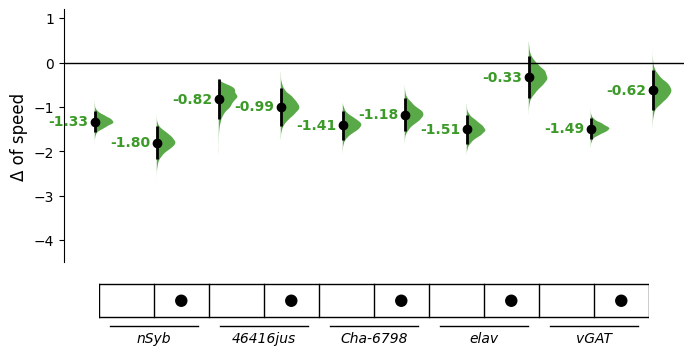

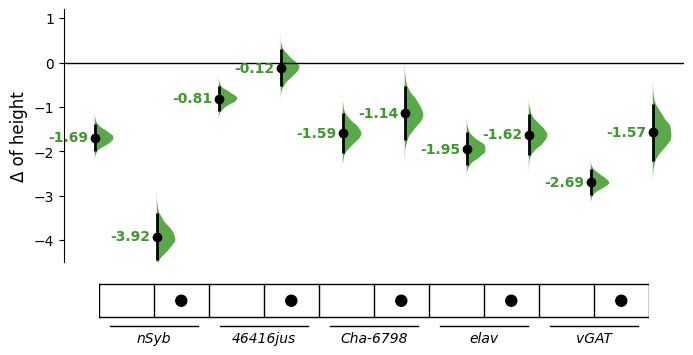

In [140]:
lstnamings = ['speed', 'height']

  
for n in lstnamings:
    dfmn, dfsmd = pergenotypeplotting(openPath, files3, n)
    g = forestplot(dfmn, dfsmd)